**N1_calibration:** Notebook for calibration of visibilities from all antennas in a given observation, as well as generating the background temperature templates.

## 1. Initialization

Initialize the computation with the necessary modules.

In [1]:
## ----- IPYTHON COMMANDS ----- ##
%load_ext autoreload
%autoreload 2


In [2]:
## ----- IMPORTS ----- ##
import satellite_RFI.src.data_reductionNEW as dr
import sys
sys.path.insert(0, './initialization/')
from imports import *
import parameters as pm  # <-- don't import for python2


## 2. Creating katdal file (python2 only!)

In order to obtain information that needs the katdal module, we need to use the python2 singularity (the python3 singularity is not compatible with the module for some reason). As such, this specific section is written in python2 and performs all computations necessary to create the katdal file with all of the information; afterwards, we just need to retrieve the file and can use python3 from the next section onward.


In [12]:
# generating katdal information file
block = 1551055211
path_results = "results_calibration/{}/".format(block)
katdal_info, obs_data = dr.generate_katdal_file(block, path_results, verbose=True)


Getting file with katdal...
Getting nd timestamps...


In [17]:
# saving information that is needed from the python2 katdal module
pickle.dump(katdal_info, open(path_results + "katdal_info.p", 'wb')) 
pickle.dump(obs_data.ants, open(path_results + "antennas.p", "wb")) 


## 3. Background temperature models

### A. Retrieving everything

We now make use of the existing calibration files on the background model in each antenna (for the unflagged regions) and then calibrate the bands that are of interest and that have been flagged from the calibration. We start by uploading the background calibrated files (which are null in the parts flagged by RFI); this takes up a lot of space, some 30GBs for all antennas. 

The background temperature model will be composed of $ T_{rec} + T_{gal} + T_{el} + T_{CMB} + C_{cons} $; this last value has to be computed after calibration of the observations themselves, and the rest of the components we'll retrieve in this section. 

TO DO: Rewrite slightly this section so that each component is gotten one at a time (like the last Tel) and saved, instead of saving them all at once which is not necessary.

In [3]:
# to debug we only analyse N_debug antennas; later put this to None or remove from the code entirely
N_debug = 6


In [4]:
# initializing data reduction object
DR = dr.DataReduction(
    block = pm.block, 
    path_cali = pm.path_cali,
    freq_range = pm.freq_range
)


In [5]:
# getting background temperatures
Trec,Tgal,Tmap,mask = DR.get_background_raws("L4", N_debug=N_debug)


Retrieving data from antennas...
	Antenna m000 successful.
	Antenna m001 successful.
	Antenna m002 successful.
	Antenna m003 successful.
	Antenna m004 successful.
	Antenna m005 successful.


In [6]:
del Trec
del Tgal
del Tmap
del mask

### B. Receiver temperature

Now, we perform calibration on the receiver temperature of each good antenna; we assume the mask of unvalid values is given by mask, and perform interpolation of the values that we have from Trec.

For the frequency-average, the level 4 mask also masks some entire time-stamps besides the usual RFI flagging of the frequency regions; however, if we use the "correctly" masked array, we return a very spotty and weird time curve since we now have some timestamps with very little points. If, instead, we just use the natural zero's mask (the data naturally has some spots where the temperature wasn't put in and it's just zeros), then we return a curve that is almost exactly like the one before, only now it's normal in its shape. As such, we will use this "incorrect" mask for the time curve. 

Comparing to Brandon's result, some previous results were way off and now we don't get those weird values, which is good!

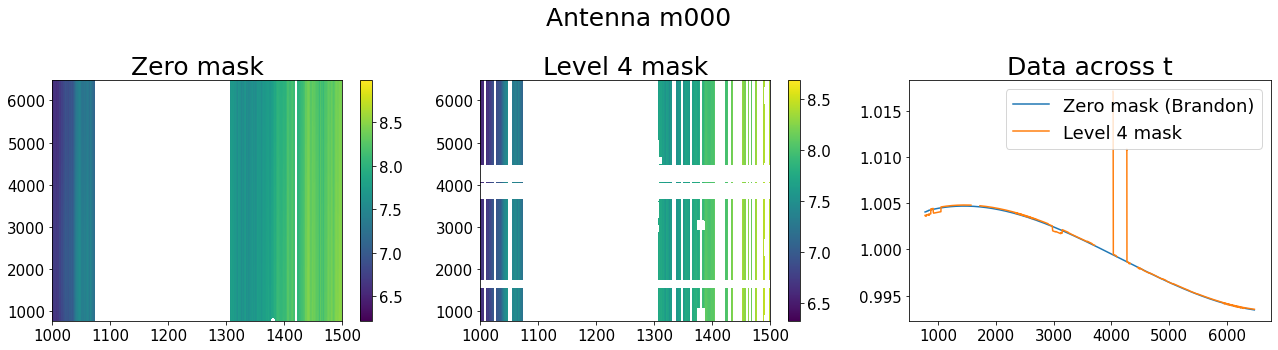

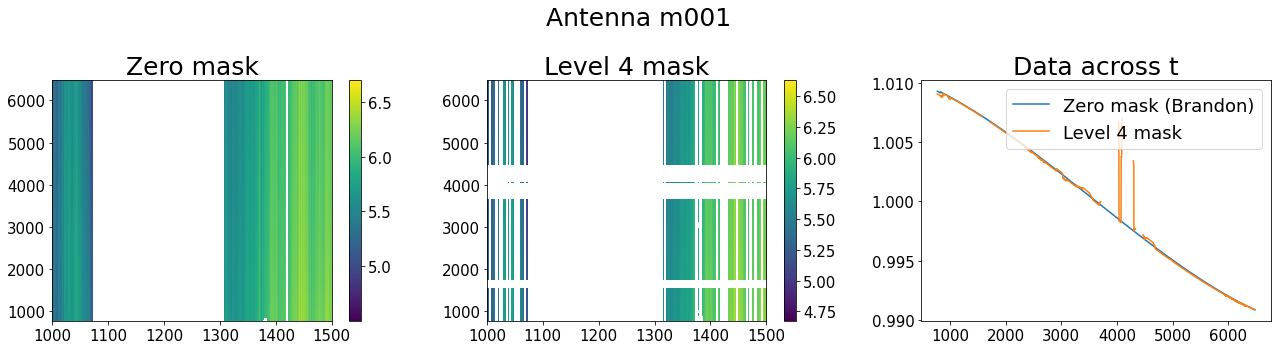

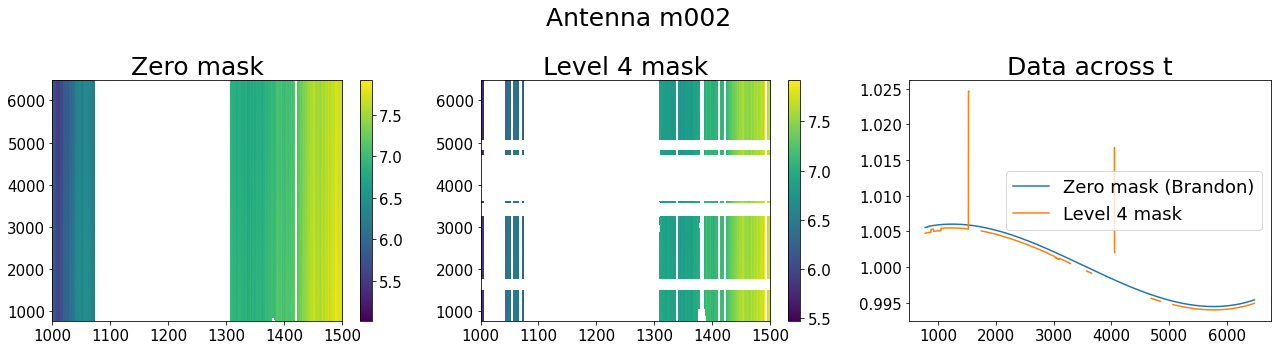

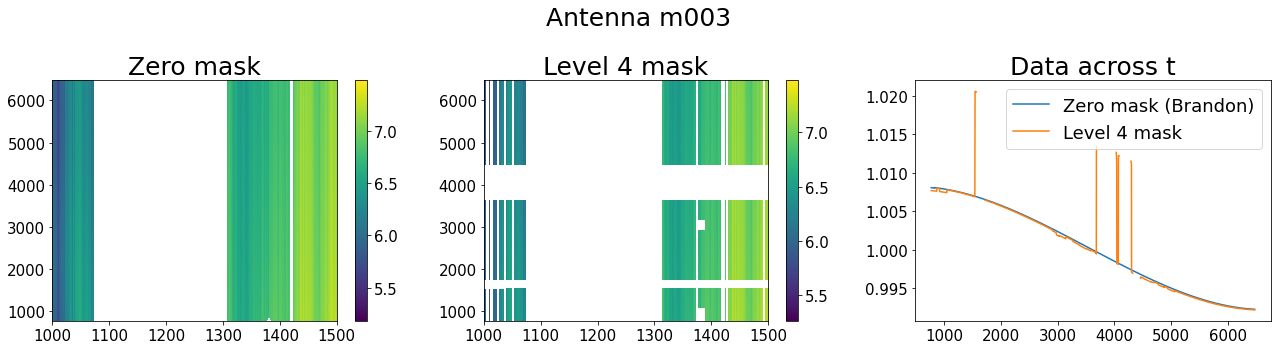

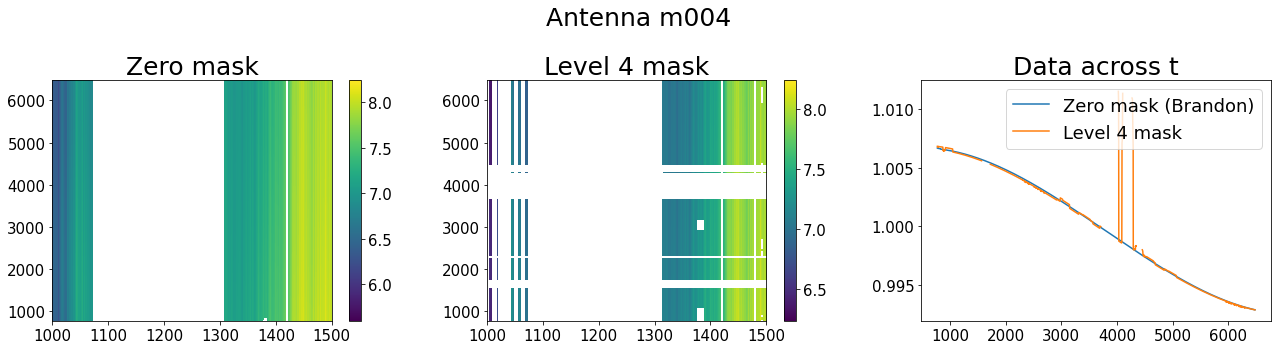

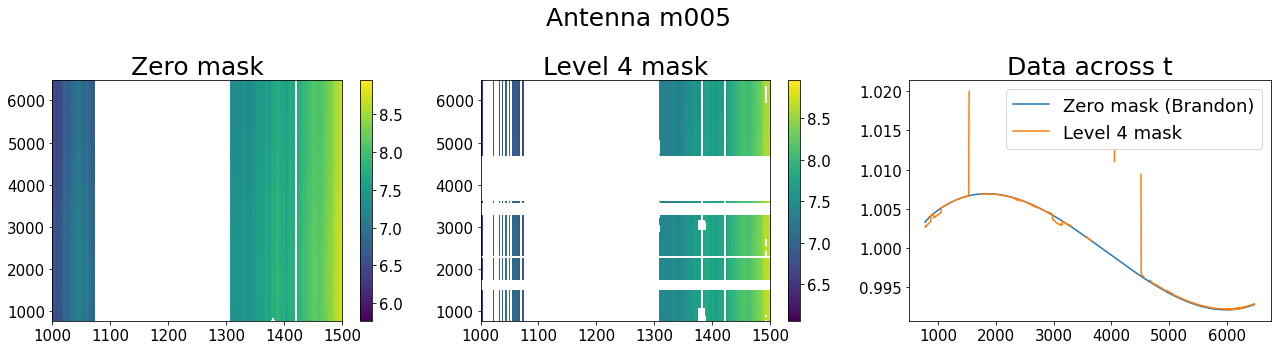

In [7]:
# comparing the two possible maskings for the time curve (frequency average)
for i,ant in enumerate(DR.good_antennas):

    # quantities
    T = Trec[i][0]
    Trec_true = np.ma.masked_array(T, mask=mask[i])
    Trec_zeros = np.ma.masked_array(T, mask=(T==0))

    # plots
    extent = [DR.frequency_cut[0], DR.frequency_cut[-1], DR.nd_s0[0], DR.nd_s0[-1]]
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))
    im1 = ax1.imshow(Trec_zeros, aspect="auto", origin="lower", extent=extent)
    fig.colorbar(im1, ax=ax1)
    ax1.set_title("Zero mask")
    im2 = ax2.imshow(Trec_true, aspect="auto", origin="lower", extent=extent)
    fig.colorbar(im2, ax=ax2)
    ax2.set_title("Level 4 mask")
    ax3.plot(DR.nd_s0, np.ma.mean(Trec_zeros, axis=1) / np.mean(Trec_zeros), label="Zero mask (Brandon)")
    ax3.plot(DR.nd_s0, np.ma.mean(Trec_true, axis=1) / np.mean(Trec_true), label="Level 4 mask")
    ax3.set_title("Data across t")
    ax3.legend()
    fig.suptitle("Antenna {}".format(ant))
    plt.tight_layout()
    plt.show()
    

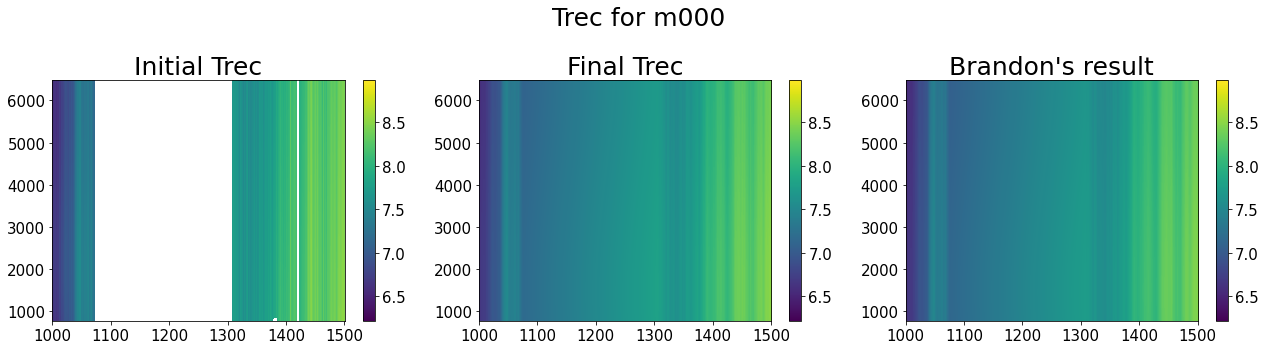

Mean residual difference to Brandon's: 0.041
Maximum residual difference to Brandon's: 0.087


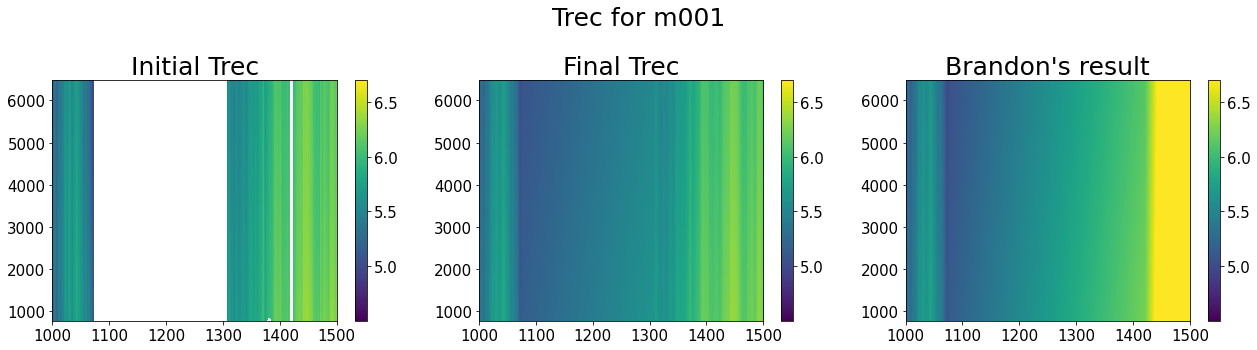

Mean residual difference to Brandon's: -0.259
Maximum residual difference to Brandon's: 0.109


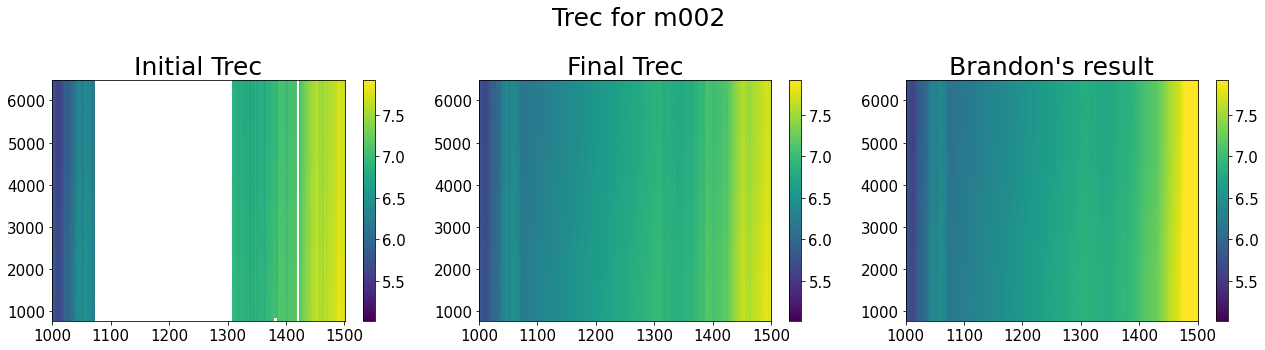

Mean residual difference to Brandon's: 0.002
Maximum residual difference to Brandon's: 0.184


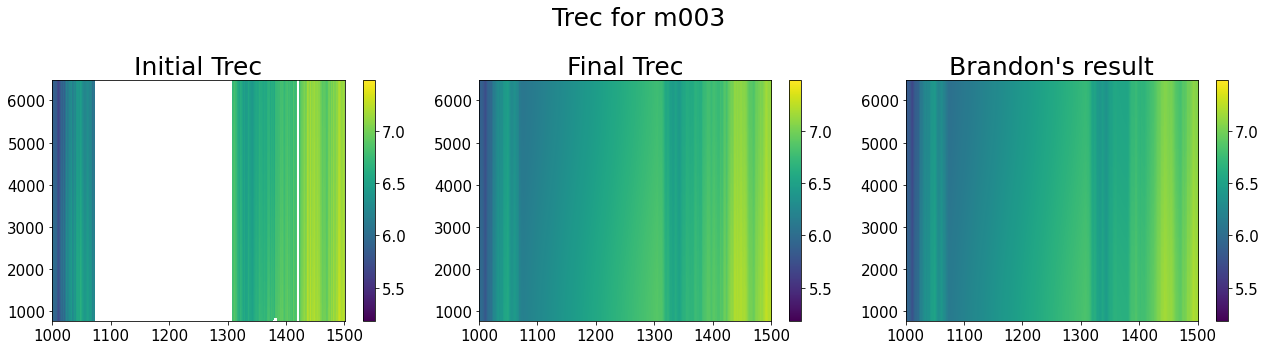

Mean residual difference to Brandon's: 0.053
Maximum residual difference to Brandon's: 0.136


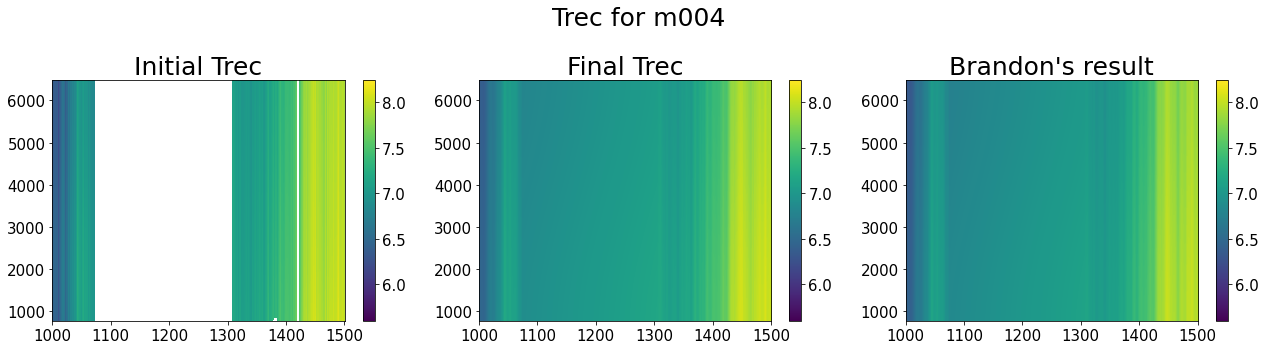

Mean residual difference to Brandon's: 0.048
Maximum residual difference to Brandon's: 0.136


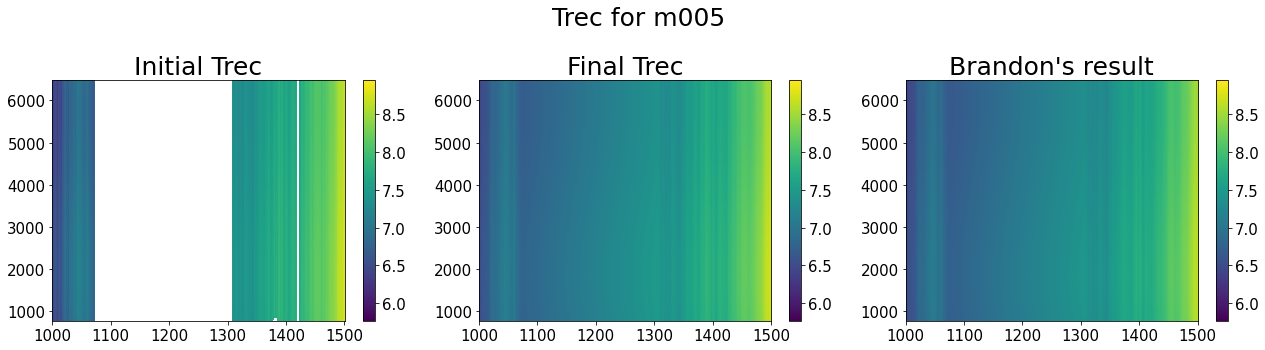

Mean residual difference to Brandon's: 0.052
Maximum residual difference to Brandon's: 0.220


In [8]:
# setting initial quantities
good_antennas_new = []

# iterating over all good antennas
for i,ant in enumerate(DR.good_antennas):
    
    # interpolating calibration
    try:
        TrecH_interp, idxH = DR.correct_Trec(Trec=Trec[i][0],mask=mask[i])
        TrecV_interp, idxV = DR.correct_Trec(Trec=Trec[i][1],mask=mask[i])
    except (ZeroDivisionError, ValueError):
        print("\tAntenna {} has bad receiver data!".format(ant))
        continue

    # creating dictionary of data
    Trec_ant = {}
    Trec_ant["H"],Trec_ant["V"] = Trec[i][0],Trec[i][1]
    Trec_ant["H_interp"],Trec_ant["V_interp"] = TrecH_interp,TrecV_interp
    Trec_ant["Hidx"],Trec_ant["Vidx"] = idxH,idxV
    good_antennas_new.append(ant)

    # getting old result
    path = "/idia/projects/hi_im/satellite_rfi/Observations/{}/{}_S1_{}_t_rec.p".format(pm.block,pm.block,ant)
    old_data = pickle.load(open(path,"rb"), encoding="latin1")["h-pol_interp"]

    # plotting newfound interpolated matrices
    extent = [DR.frequency_cut[0], DR.frequency_cut[-1], DR.nd_s0[0], DR.nd_s0[-1]]
    vmin = min(np.ma.min(np.ma.masked_equal(Trec_ant["H"],0)), np.min(Trec_ant["H_interp"]))
    vmax = max(np.max(Trec_ant["H"]), np.max(Trec_ant["H_interp"]))
    fig, (ax1,ax2,ax3) = plt.subplots(1, 3, figsize=(18, 5))
    im1 = ax1.imshow(np.ma.masked_equal(Trec_ant["H"],0),aspect="auto",origin="lower",extent=extent,vmin=vmin,vmax=vmax)
    fig.colorbar(im1, ax=ax1)
    ax1.set_title("Initial Trec")
    im2 = ax2.imshow(Trec_ant["H_interp"],aspect="auto",origin="lower",extent=extent,vmin=vmin,vmax=vmax)
    fig.colorbar(im2, ax=ax2)
    ax2.set_title("Final Trec")
    im3 = ax3.imshow(old_data,aspect="auto",origin="lower",extent=extent,vmin=vmin,vmax=vmax)
    fig.colorbar(im3, ax=ax3)
    ax3.set_title("Brandon's result")
    plt.suptitle("Trec for {}".format(ant))
    plt.tight_layout()
    plt.show()
    print("Mean residual difference to Brandon's: {:.3f}".format(np.mean(Trec_ant["H_interp"]-old_data)))
    print("Maximum residual difference to Brandon's: {:.3f}".format(np.max(Trec_ant["H_interp"]-old_data)))

    # saving data
    pickle.dump(Trec_ant, open(pm.path_cali + "{}_Trec.p".format(ant),"wb"))
DR.good_antennas = good_antennas_new


### B. Galactic temperature

For the galactic temperature we don't require any further calibration and so just save the results we already have from the calibration.

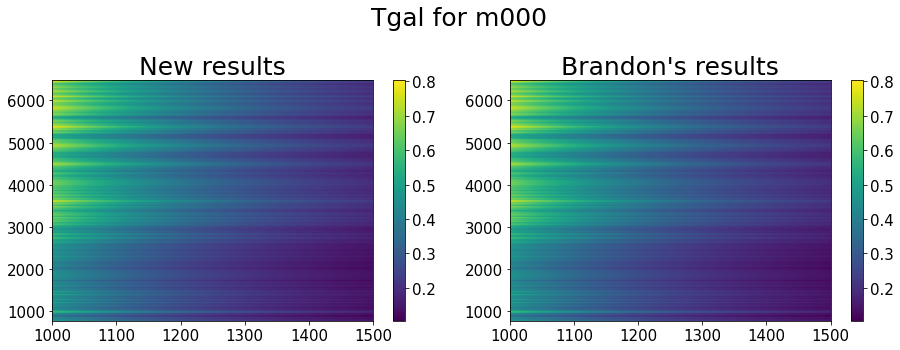

Mean residual difference to Brandon's: 0.000
Maximum residual difference to Brandon's: 0.000


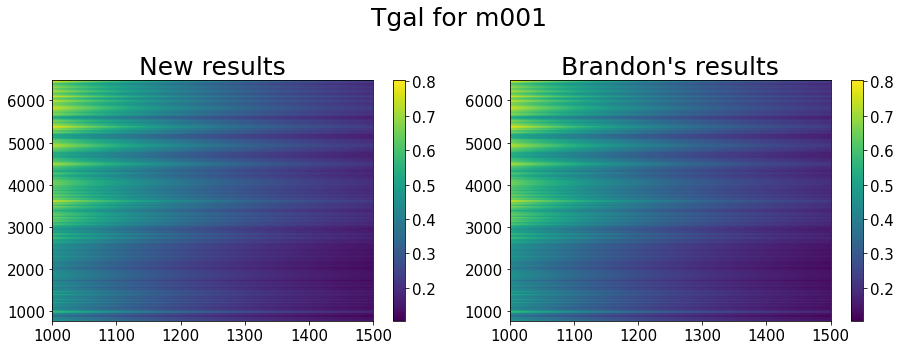

Mean residual difference to Brandon's: 0.000
Maximum residual difference to Brandon's: 0.000


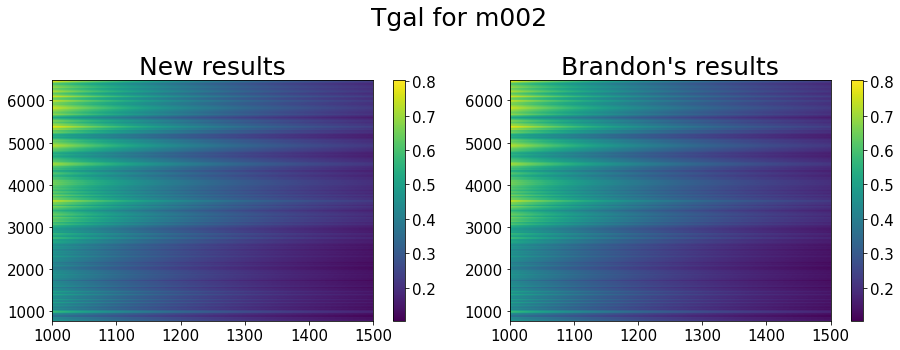

Mean residual difference to Brandon's: 0.000
Maximum residual difference to Brandon's: 0.000


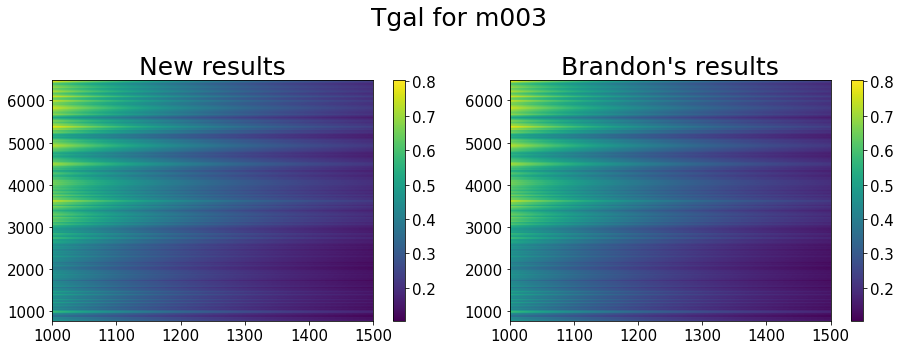

Mean residual difference to Brandon's: 0.000
Maximum residual difference to Brandon's: 0.000


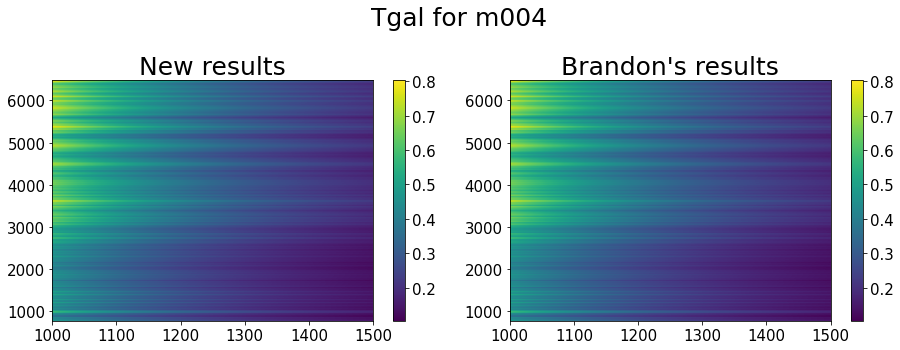

Mean residual difference to Brandon's: 0.000
Maximum residual difference to Brandon's: 0.000


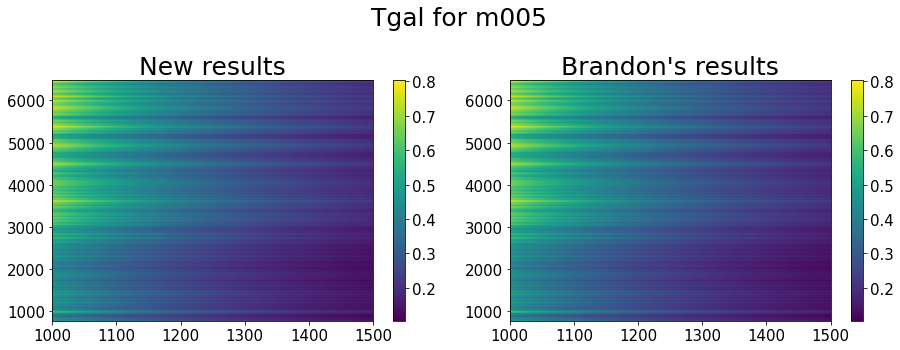

Mean residual difference to Brandon's: 0.000
Maximum residual difference to Brandon's: 0.000


In [20]:
# iterating over each antenna
for i,ant in enumerate(DR.good_antennas):
    # getting new values
    Tgal_ant = {}
    Tgal_ant["H"] = Tgal[i][0]
    Tgal_ant["V"] = Tgal[i][1]
    pickle.dump(Tgal_ant, open(pm.path_cali + "{}_Tgal.p".format(ant),"wb"))

    # getting old values
    path = "/idia/projects/hi_im/satellite_rfi/Observations/{}/{}_S1_{}_t_gal.p".format(pm.block,pm.block,ant)
    old_data = pickle.load(open(path,"rb"), encoding="latin1")["h-pol"]
    vmin = min([np.ma.min(Tgal_ant["H"]),np.ma.min(old_data)])
    vmax = max([np.ma.max(Tgal_ant["H"]),np.ma.max(old_data)])
    
    # plotting
    fig, (ax1,ax2) = plt.subplots(1, 2, figsize=(13, 5))
    extent = [DR.frequency_cut[0], DR.frequency_cut[-1], DR.nd_s0[0], DR.nd_s0[-1]]
    im1 = ax1.imshow(Tgal_ant["H"],aspect="auto",origin="lower",extent=extent,vmin=vmin,vmax=vmax)
    fig.colorbar(im1, ax=ax1)
    ax1.set_title("New results")
    im2 = ax2.imshow(old_data,aspect="auto",origin="lower",extent=extent,vmin=vmin,vmax=vmax)
    fig.colorbar(im2, ax=ax2)
    ax2.set_title("Brandon's results")
    
    plt.suptitle("Tgal for {}".format(ant))
    plt.tight_layout()
    plt.show()
    print("Mean residual difference to Brandon's: {:.3f}".format(np.mean(Tgal_ant["H"]-old_data)))
    print("Maximum residual difference to Brandon's: {:.3f}".format(np.max(Tgal_ant["H"]-old_data)))


### C. Elevation temperature

Now we do the same thing with the elevation temperature; in this case, if we find a weird bump in the data (a "spike") in the time domain, we interpolate the spiked data (because as the antennas are stationary there should not be any noticeable variation in the elevation temperature with time). 

Getting elevation temperatures...


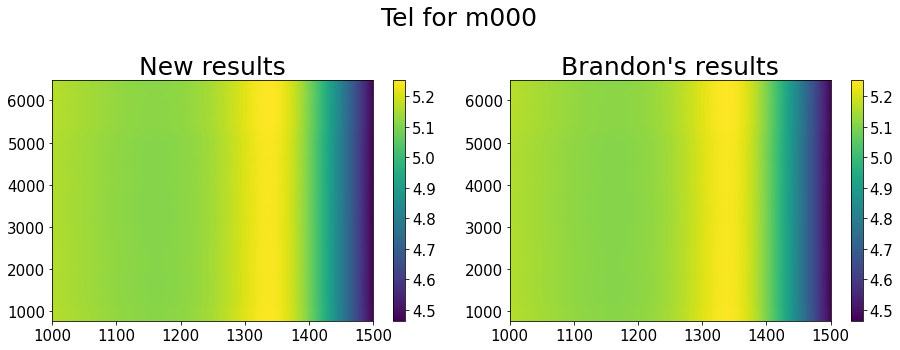

Mean residual difference to Brandon's: -0.232
Maximum residual difference to Brandon's: -0.060


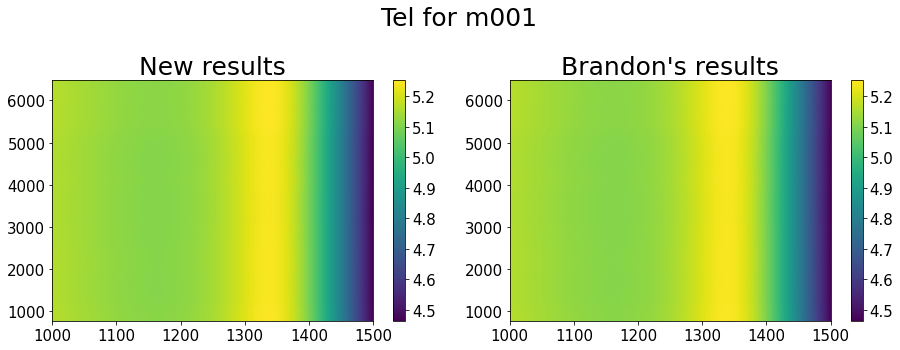

Mean residual difference to Brandon's: -0.232
Maximum residual difference to Brandon's: -0.060


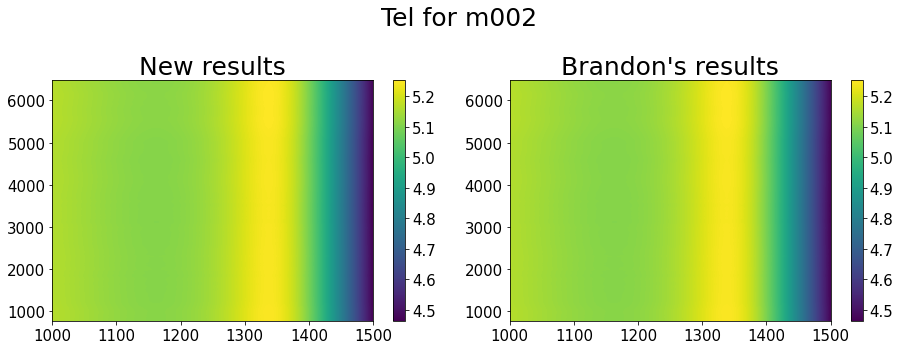

Mean residual difference to Brandon's: -0.232
Maximum residual difference to Brandon's: -0.060


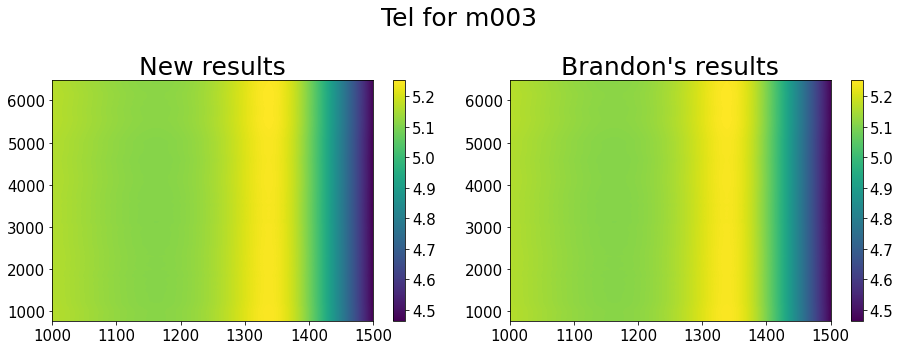

Mean residual difference to Brandon's: -0.232
Maximum residual difference to Brandon's: -0.060


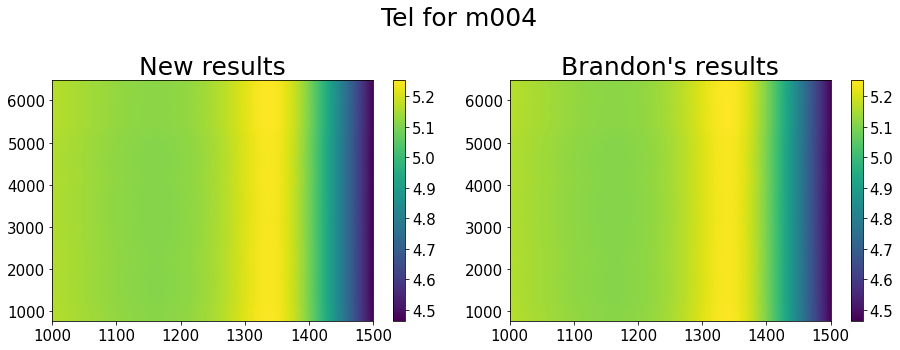

Mean residual difference to Brandon's: -0.232
Maximum residual difference to Brandon's: -0.060


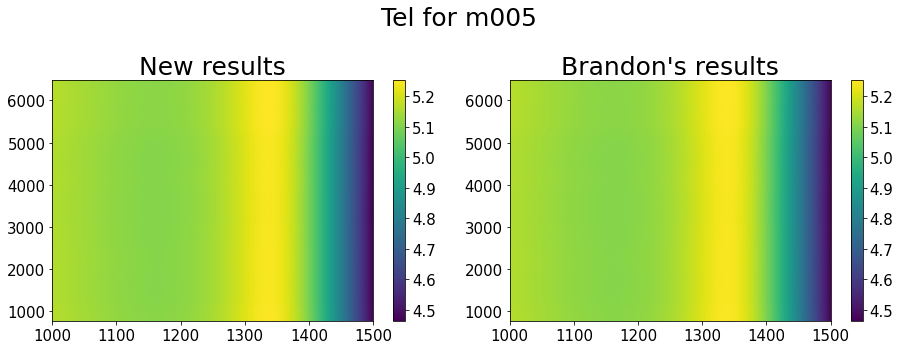

Mean residual difference to Brandon's: -0.232
Maximum residual difference to Brandon's: -0.060


In [23]:
# iterating over each antenna
print("Getting elevation temperatures...")
for i,ant in enumerate(DR.good_antennas):

    # getting data
    path = "/idia/projects/hi_im/satellite_rfi/misc_data/T_elevation_jobs/{}_{}".format(pm.block,ant)
    dataH = pickle.load(open(path + "h_full_t_el", "rb"), encoding="latin1")
    dataV = pickle.load(open(path + "v_full_t_el", "rb"), encoding="latin1")

    # creating dictionary
    Tel_ant = {}
    Tel_ant["H"] = dataH['Tel_map'][DR.ifreq[0]:DR.ifreq[1], DR.nd_s0_pos].T
    Tel_ant["V"] = dataV['Tel_map'][DR.ifreq[0]:DR.ifreq[1], DR.nd_s0_pos].T
    Tel_ant["H_interp"],spike_foundH = DR.correct_Tel(Tel_ant["H"])
    Tel_ant["V_interp"],spike_foundV = DR.correct_Tel(Tel_ant["V"])
    if spike_foundH or spike_foundV:  print("\tAntenna {} had 1 spike.".format(ant))

    # saving data
    pickle.dump(Tel_ant, open(pm.path_cali + "{}_Tel.p".format(ant),"wb"))

    # getting old values
    path = "/idia/projects/hi_im/satellite_rfi/Testing/{}/{}_{}_t_el.p".format(pm.block,pm.block,ant)
    old_data = pickle.load(open(path,"rb"), encoding="latin1")["v-pol"]
    vmin = min([np.ma.min(Tel_ant["V_interp"]),np.ma.min(old_data)])
    vmax = max([np.ma.max(Tel_ant["V_interp"]),np.ma.max(old_data)])
    
    # plotting
    fig, (ax1,ax2) = plt.subplots(1, 2, figsize=(13, 5))
    extent = [DR.frequency_cut[0], DR.frequency_cut[-1], DR.nd_s0[0], DR.nd_s0[-1]]
    im1 = ax1.imshow(Tel_ant["V_interp"],aspect="auto",origin="lower",extent=extent,vmin=vmin,vmax=vmax)
    fig.colorbar(im1, ax=ax1)
    ax1.set_title("New results")
    im2 = ax2.imshow(old_data,aspect="auto",origin="lower",extent=extent,vmin=vmin,vmax=vmax)
    fig.colorbar(im2, ax=ax2)
    ax2.set_title("Brandon's results")
    
    plt.suptitle("Tel for {}".format(ant))
    plt.tight_layout()
    plt.show()
    print("Mean residual difference to Brandon's: {:.3f}".format(np.mean(Tel_ant["H"]-old_data)))
    print("Maximum residual difference to Brandon's: {:.3f}".format(np.max(Tel_ant["H"]-old_data)))


## 4. Calibrating antennas' visibilities and gain

Now we perform the calibration on the raw visibility files, to calibrate the RFI-flagged region as well. This part of the code is where the original notebook chose only to calibrate the first available antenna, and so we will just iterate over all antennas the procedure that he previously performed only on the first, assuming that we can generalize for all of them.


### A. Retrieving initial quantities and plotting

It would be probably better to divide this first section into the visibilities and gains, and to delete several of these quantities, but I'm not sure yet which quantities will be useful overall and which quantities are just for one or other plot. 

In the final code, it appears that Brandon doesn't use the level 4 mask, but he still uses the _clean_outliers function which puts a mask on the gain. However, when we observe what it does it very clearly just masks the values that were already zero in the gain. As such, for now we will use a **zeros mask** instead of the _clean_outliers for both the visibilities (but doesn't seem to be necessary as >0 always) and for the gain, as it more clearly states what the final value is, and then we just need to check that it in fact does that for all antenna gains. 

However, for the first part of the **frequency bandpass calculation the code uses level 4 mask** as well; as such we will add it, and if we want to remove it later we just take the data and mask by zero!


Some notes:
- The gain and visibility (total) are plotted assuming that the original range of the timestamps is the same as the range of the cut timestamps (nd_s0); we can later check if this is true, but he also assumes this in his thesis.
- The visibilities look different from the thesis! They look like they are a bit higher in their overall numbers - check this with mean in time and frequency.
- The gain is also masked in an additional strip and I don't know why, but might be why the mean is slightly lower in one of the means.
Resolved: this was because Brandon is not cutting the frequency range, and instead using the "natural" range that the gain is calibrated - it's *almost* 1000-1500, but not quite and has a few non-null values outside of this range, which accounted for the slight differences in the graphics!!!!!

In [7]:
# creating quantities -- we now are storing quantities in dictionaries
visH,visV,gainH,gainV,mask = {},{},{},{},{}

# iterating over each antenna and saving
print("Getting gains and visibilities")
for i,ant in enumerate(DR.good_antennas):
    print(f"\tAntenna {ant}...")
    visH[ant], visV[ant], gainH[ant], gainV[ant], mask[ant] = DR.get_gain_raws(ant,masked=True)


Getting gains and visibilities
	Antenna m000...
	Antenna m001...
	Antenna m002...
	Antenna m003...
	Antenna m004...
	Antenna m005...


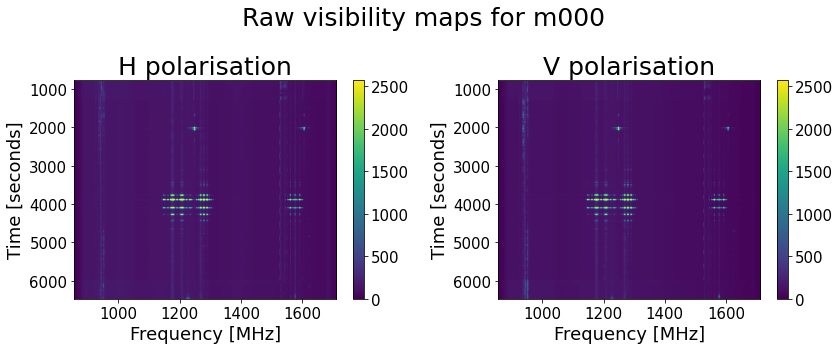

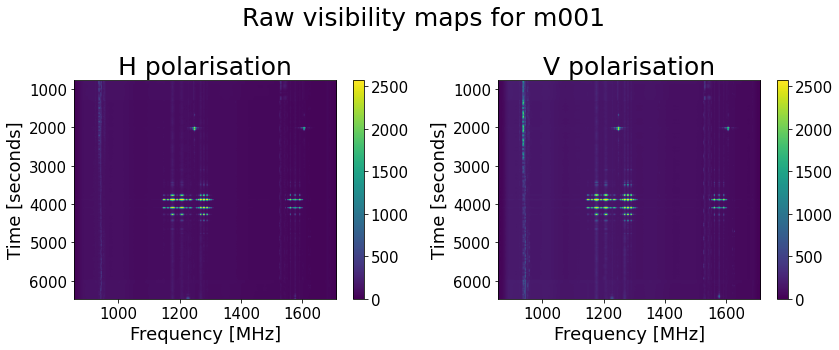

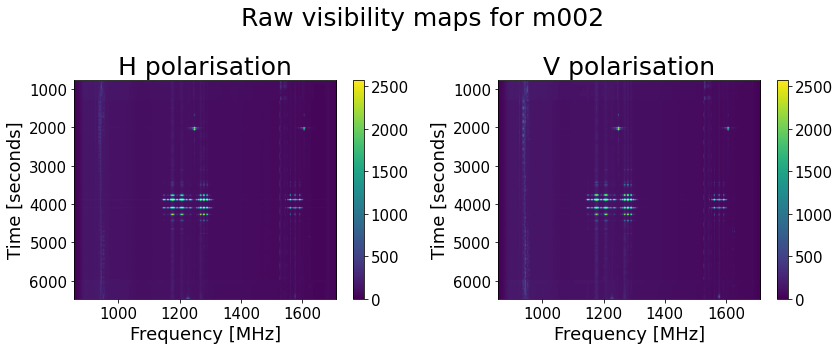

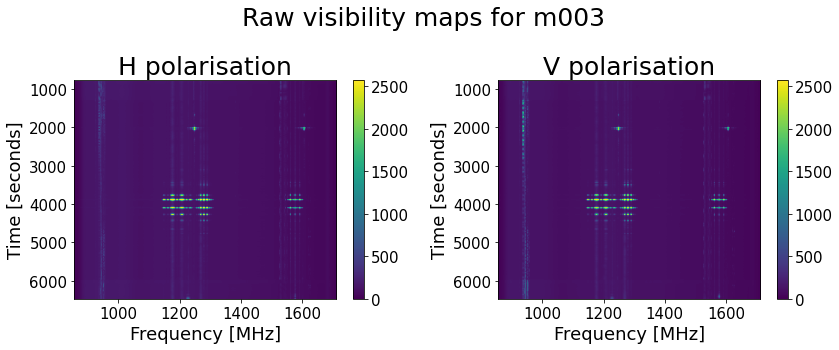

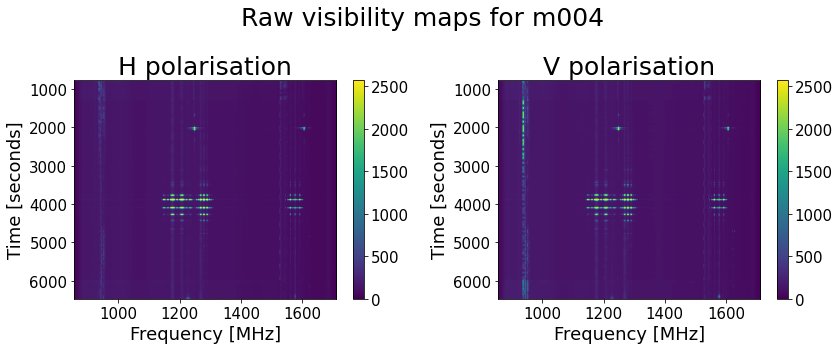

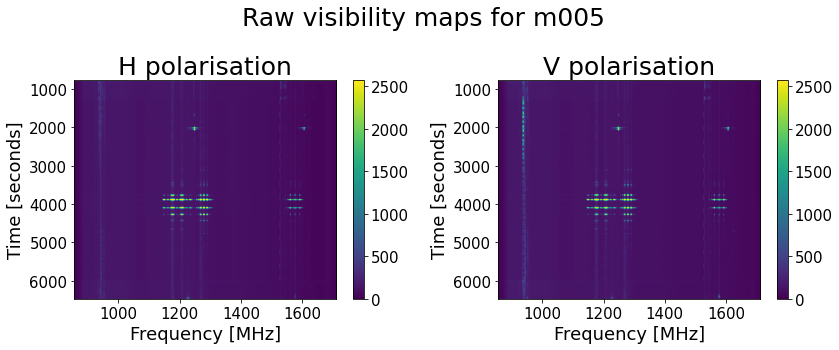

In [184]:
# plotting raw visibilities
for i,ant in enumerate(DR.good_antennas):
    
    # defining quantities
    extent = [DR.frequency[0], DR.frequency[-1], DR.nd_s0[-1], DR.nd_s0[0]]
    vmax,vmin = np.max([visH[ant],visV[ant]]), np.min([visH[ant],visV[ant]])
    labels = ["H","V"]
    
    # plotting raw visibilities
    fig,axs = plt.subplots(figsize=(12, 5), ncols=2, nrows=1)
    for i,vis in enumerate([visH[ant],visV[ant]]):
        im = axs[i].imshow(vis, aspect='auto', extent=extent,vmin=vmin,vmax=vmax)
        cb = fig.colorbar(im, ax=axs[i])
        axs[i].set_title('{} polarisation'.format(labels[i]))
        axs[i].set_ylabel('Time [seconds]')
        axs[i].set_xlabel('Frequency [MHz]')

    # creating figure
    fig.suptitle("Raw visibility maps for {}".format(ant))
    fig.tight_layout()
    plt.show()


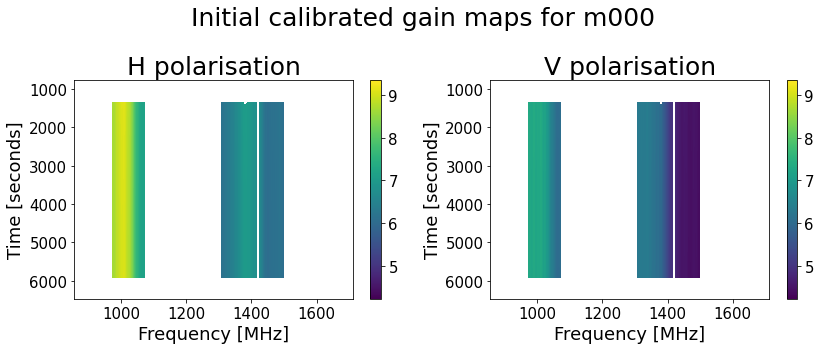

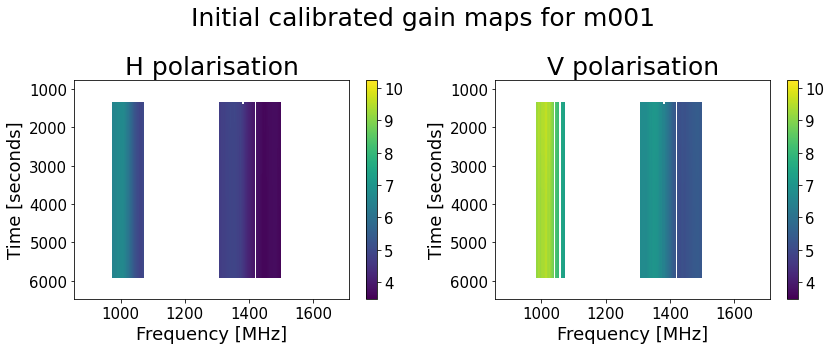

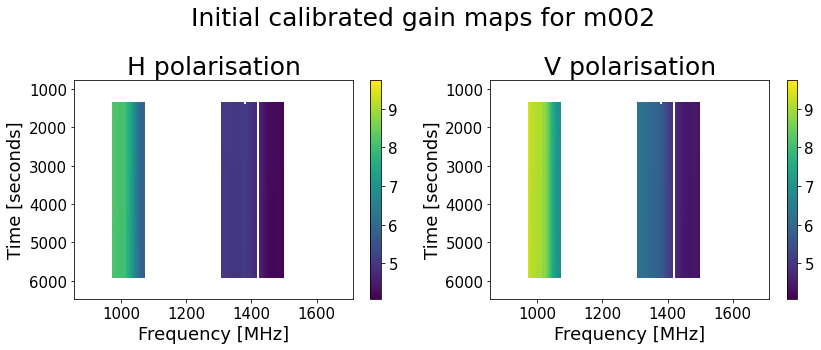

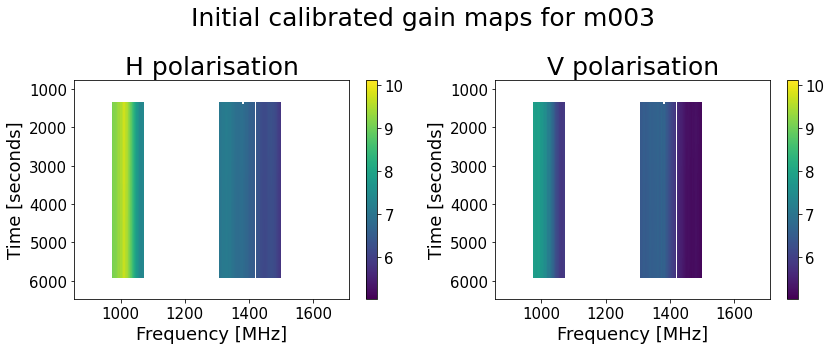

In [ ]:
# plotting gains
for i,ant in enumerate(DR.good_antennas):
    
    # defining quantities
    extent = [DR.frequency[0], DR.frequency[-1], DR.nd_s0[-1], DR.nd_s0[0]]
    vmax,vmin = np.ma.max([gainH[ant],gainV[ant]]), np.ma.min([gainH[ant],gainV[ant]])
    labels = ["H","V"]
    
    # plotting raw gains
    fig,axs = plt.subplots(figsize=(12, 5), ncols=2, nrows=1)
    for i,gain in enumerate([gainH[ant],gainV[ant]]):
        im = axs[i].imshow(gain, aspect='auto', extent=extent, vmax=vmax, vmin=vmin)
        cb = fig.colorbar(im, ax=axs[i])
        axs[i].set_title('{} polarisation'.format(labels[i]))
        axs[i].set_ylabel('Time [seconds]')
        axs[i].set_xlabel('Frequency [MHz]')

    # creating figure
    fig.suptitle("Initial calibrated gain maps for {}".format(ant))
    fig.tight_layout()
    plt.show()


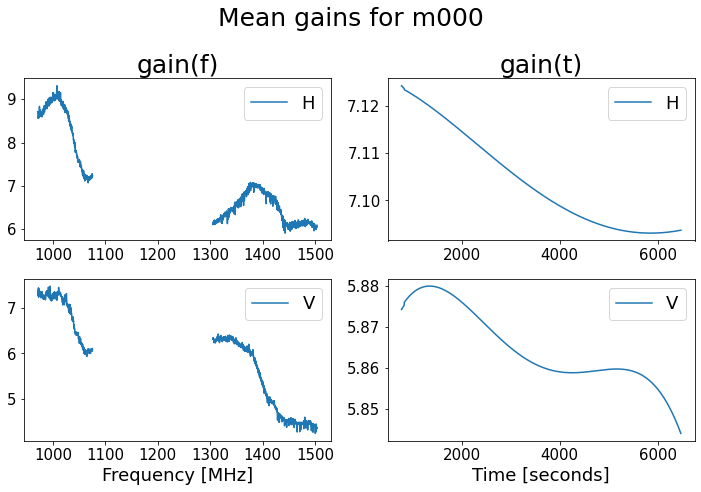

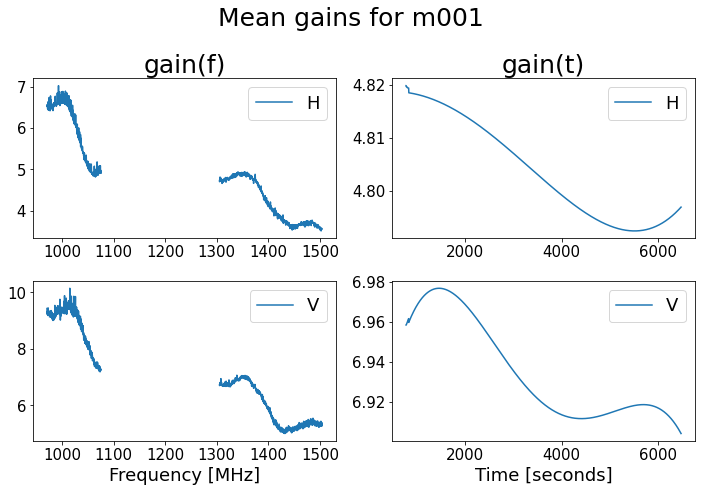

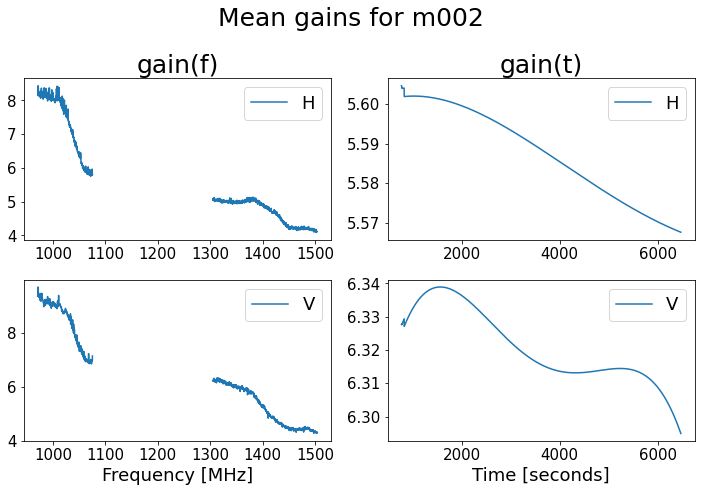

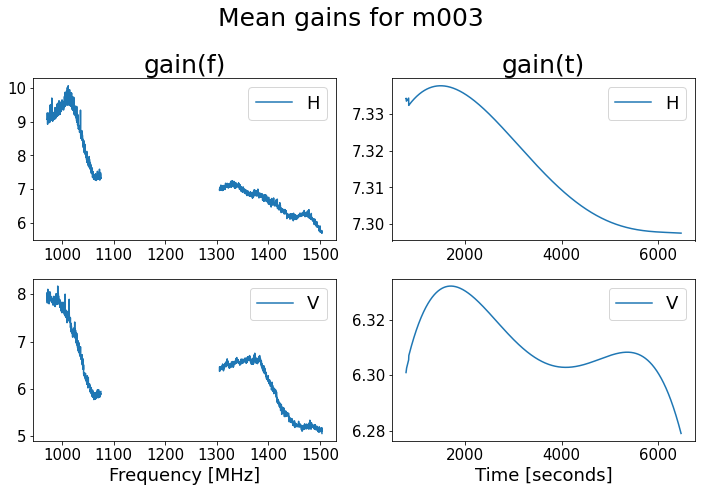

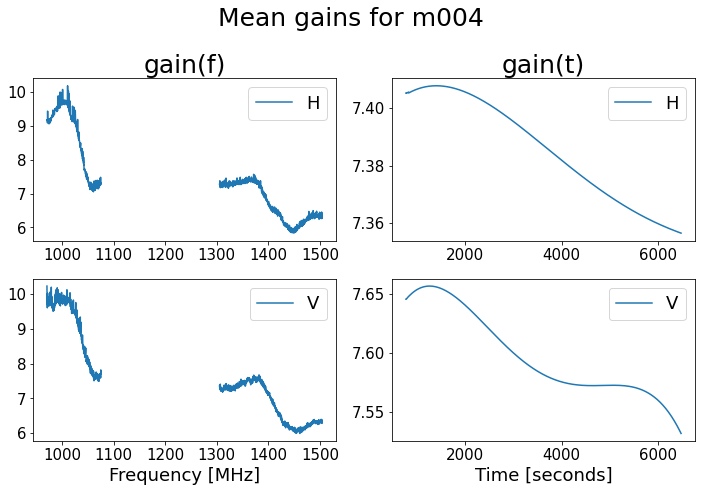

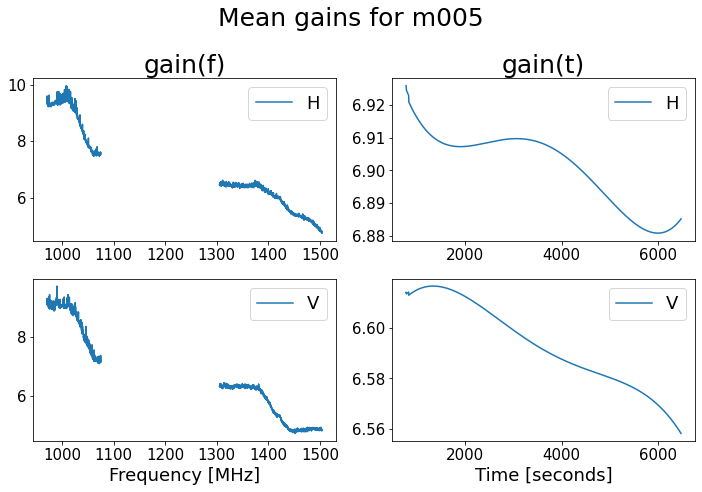

In [8]:
# plotting gain curves in frequency and time
for ant in DR.good_antennas:

    # defining quantities -- HE USES ALL FREQUENCIES BUT CUTS THE TIMES, MAKES SENSE!
    gH = gainH[ant][DR.nd_s0_pos, :]
    gV = gainV[ant][DR.nd_s0_pos, :]
    labels = ["H","V"]

    # plotting
    fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(10, 7))
    for i,gain in enumerate([gH,gV]):
        for j,xs in enumerate([DR.frequency,DR.nd_s0]):
            axs[i,j].plot(xs, np.ma.mean(gain, axis=j), label=labels[i])
            axs[i,j].legend()
    axs[0,0].set_title("gain(f)")
    axs[0,1].set_title("gain(t)")
    axs[1,0].set_xlabel("Frequency [MHz]")
    axs[1,1].set_xlabel("Time [seconds]")
    fig.suptitle("Mean gains for {}".format(ant))
    fig.tight_layout()
    plt.show()
    

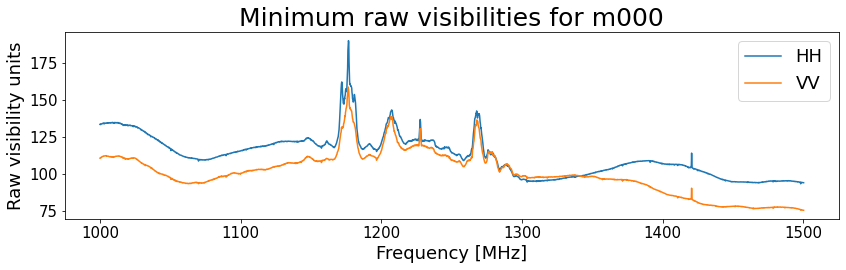

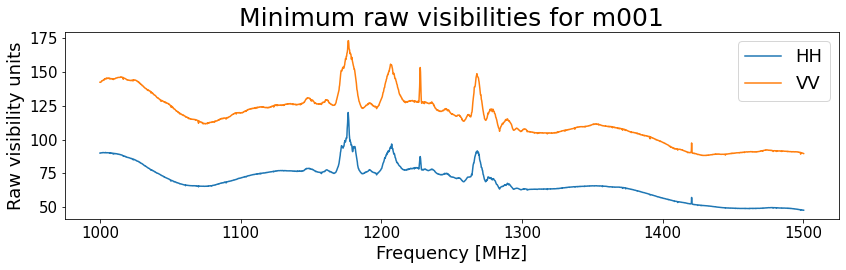

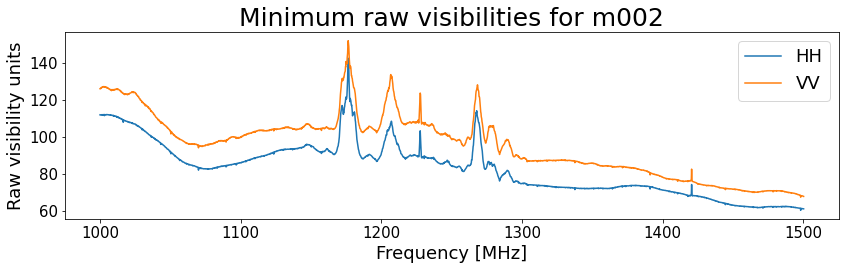

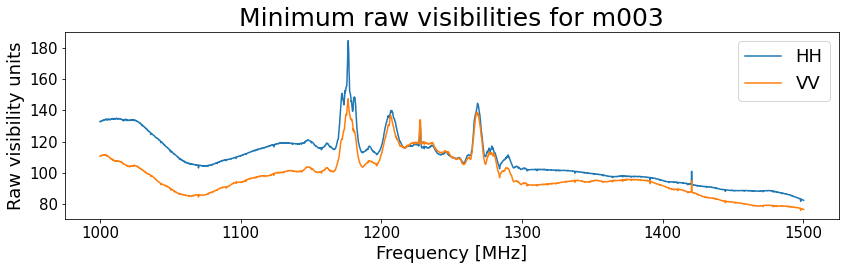

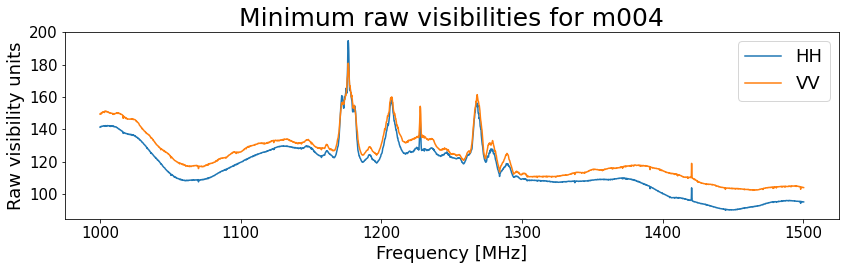

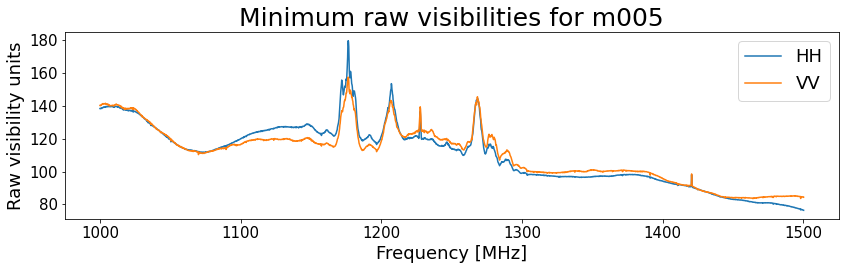

In [10]:
# plotting minimum raw visibilities
visV_min,visH_min = {},{}
for i,ant in enumerate(DR.good_antennas):

    # calculating necessary quantities
    visH_min[ant] = np.ma.min(visH[ant][DR.nd_s0_pos,DR.ifreq[0]:DR.ifreq[1]], axis=0)
    visV_min[ant] = np.ma.min(visV[ant][DR.nd_s0_pos,DR.ifreq[0]:DR.ifreq[1]], axis=0)
    
    # plotting
    fig,ax = plt.subplots(figsize=(12, 4), nrows=1, ncols=1)
    ax.plot(DR.frequency_cut, visH_min[ant], label="HH")
    ax.plot(DR.frequency_cut, visV_min[ant], label="VV")
    ax.set_ylabel('Raw visibility units')
    ax.set_xlabel('Frequency [MHz]')
    ax.set_title("Minimum raw visibilities for {}".format(ant))
    ax.legend()
    fig.tight_layout()
    plt.show()


### B. Calculating frequency bandpass from the visibility

We now perform the visibility calibration, performing a polynomial fit to the data and removing outliers iteratively. For now, the parameters don't seem optimal for several of the antennas and it would be wise to change them, but during debug we'll let this pass because the results are passable (just not very good overall). The result obtained for the first antenna is exactly Brandon's result shown in the thesis.

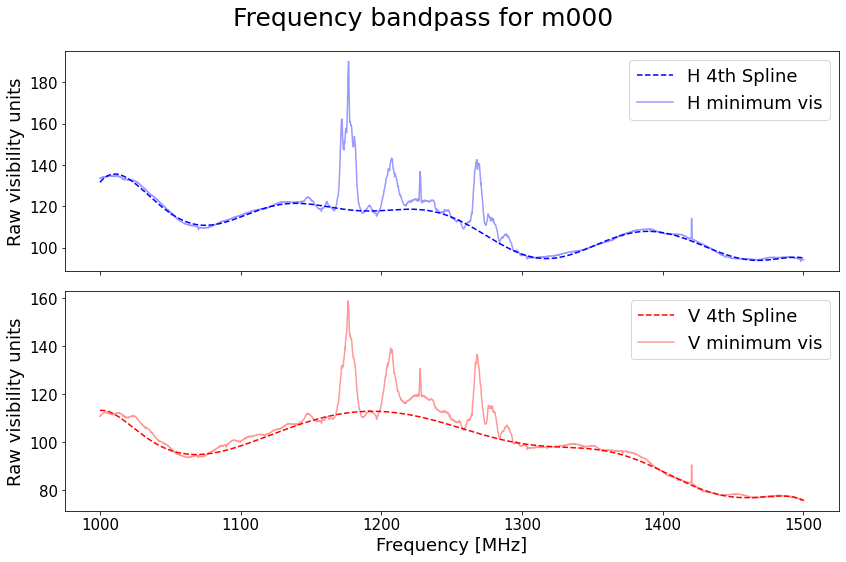

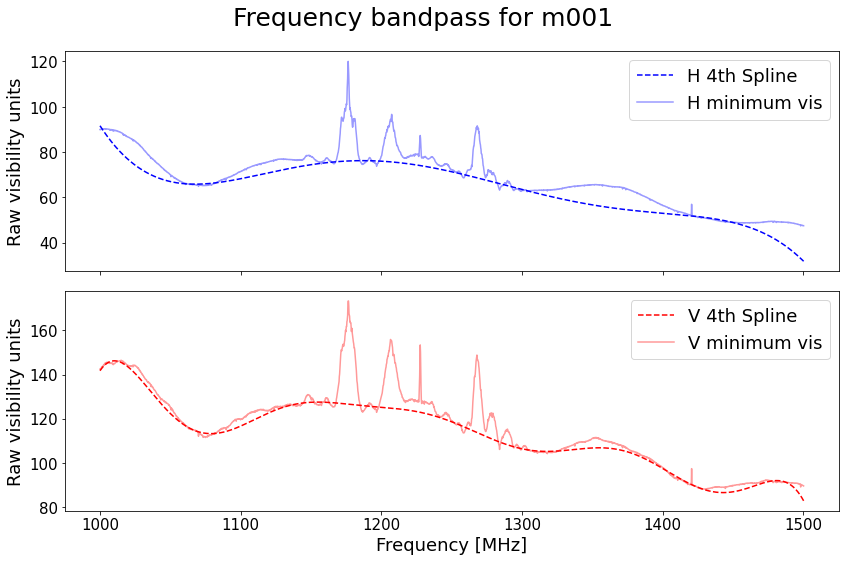

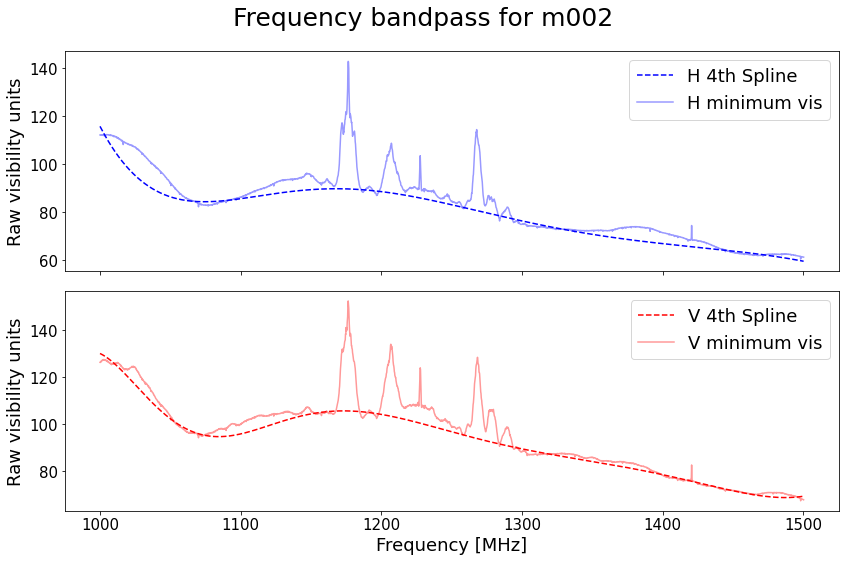

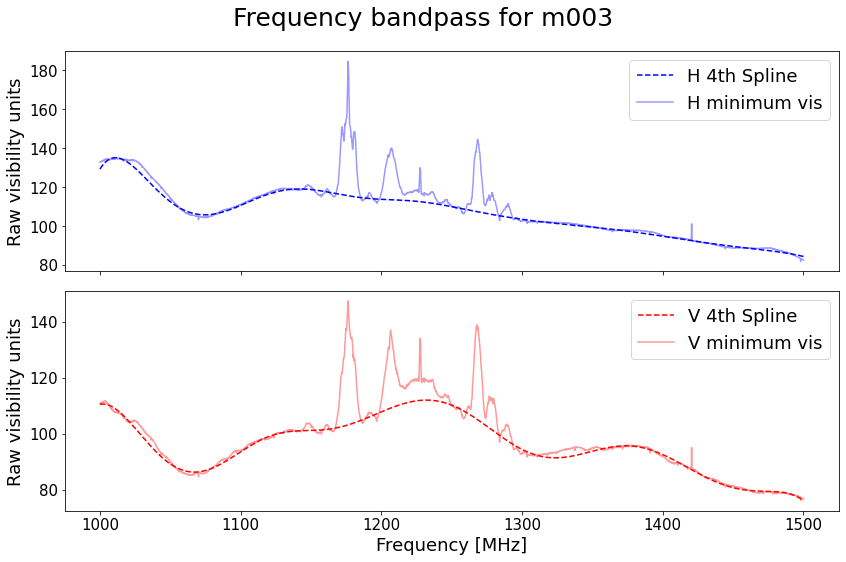

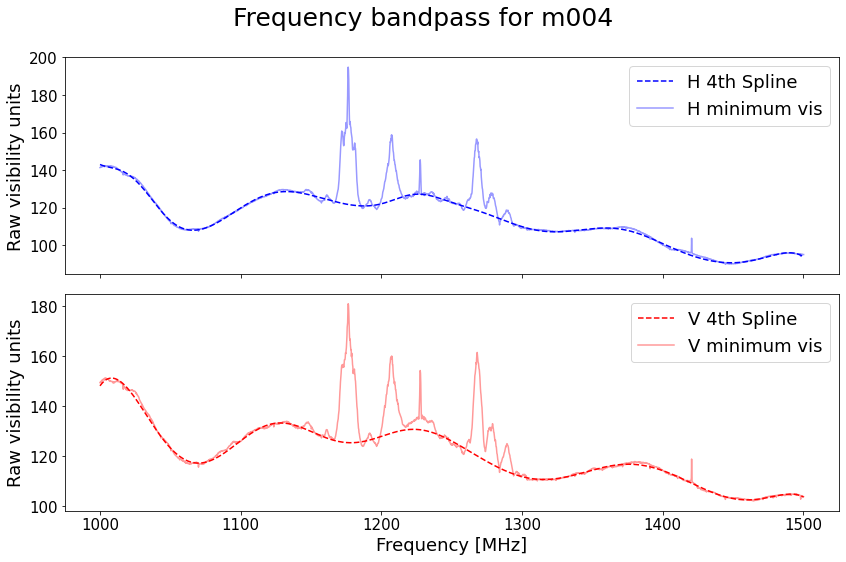

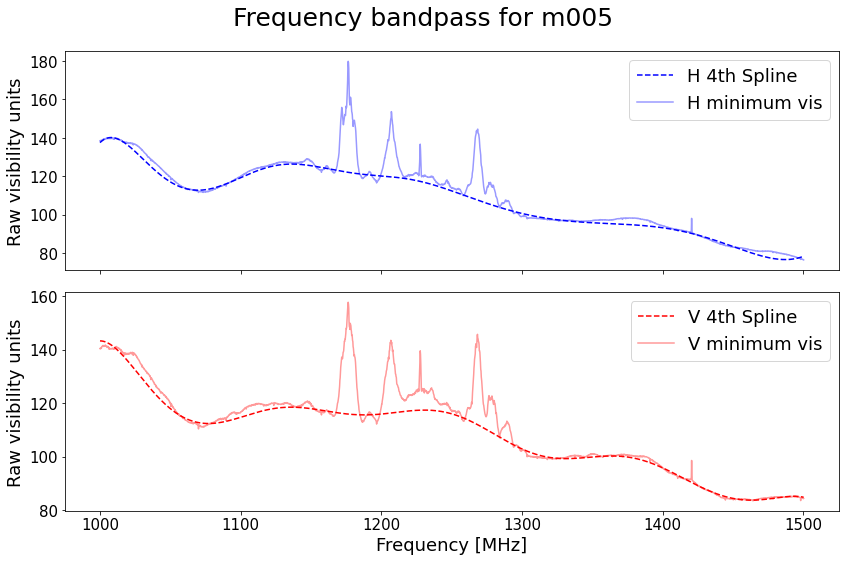

In [11]:
# saving quantities
bpH,bpV = {},{}

for ant in DR.good_antennas:

    # calculating bandpass and plot quantities
    bpH[ant] = DR.get_frequency_bandpass(vis_min=visH_min[ant], smooth=[5e4, 8e3, 1e3, 1e3])
    bpV[ant] = DR.get_frequency_bandpass(vis_min=visV_min[ant], smooth=[5e4, 8e3, 1e3, 1e3])
    vis = [visH_min[ant], visV_min[ant]]
    labels = ["H","V"]
    colors = ["b","r"]

    # plotting
    fig,axs = plt.subplots(figsize=(12, 8), nrows=2, ncols=1, sharex=True)
    for i,bp in enumerate([bpH[ant],bpV[ant]]):
        axs[i].plot(DR.frequency_cut, bp, colors[i]+"--", label="{} 4th Spline".format(labels[i]))
        axs[i].plot(DR.frequency_cut, vis[i], colors[i]+"-", alpha=0.4, 
                    label="{} minimum vis".format(labels[i]))
        axs[i].set_ylabel('Raw visibility units')
        axs[i].legend()

    # creating figure
    axs[1].set_xlabel("Frequency [MHz]")
    fig.suptitle(r"Frequency bandpass for {}".format(ant))
    fig.tight_layout()
    plt.show()


### C. Calculating final gain curve

We now calculate the final gain curve. The original notebook also performs a lot of additional calculations and plots but none of those quantities are saved in the final file, and so we will skip these for now.

Now we need to use different values for the norm, since the gain now has slightly different values (I think because we have a null strip of values, where Brandon had non-null values... Not sure how to tackle this). 

In [100]:
# global quantities to define
norms = {
    "m000": [0.98, 0.99],
    "m001": [1, 0.93],
    "m002": [0.96, 0.97],
    "m003": [0.94, 0.95],
    "m004": [0.95, 0.97],
    "m005": [0.95, 0.94],
}
freq_slices = [(1138,1307), (1100,1314)]  # <-- para a primeira antena manter estes!!
#freq_slices = (1090,1290)  # <-- para as restantes pode ser estes
labels = ["H","V"]


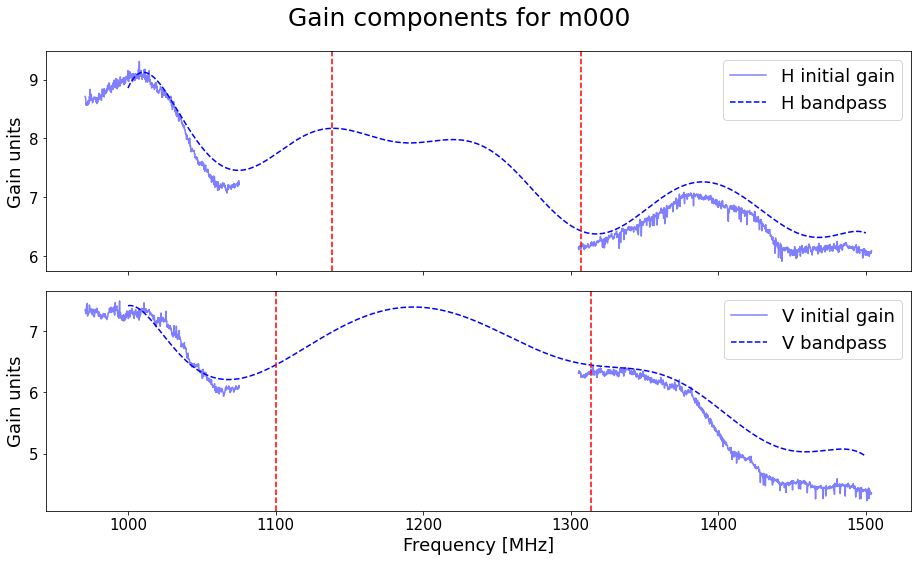

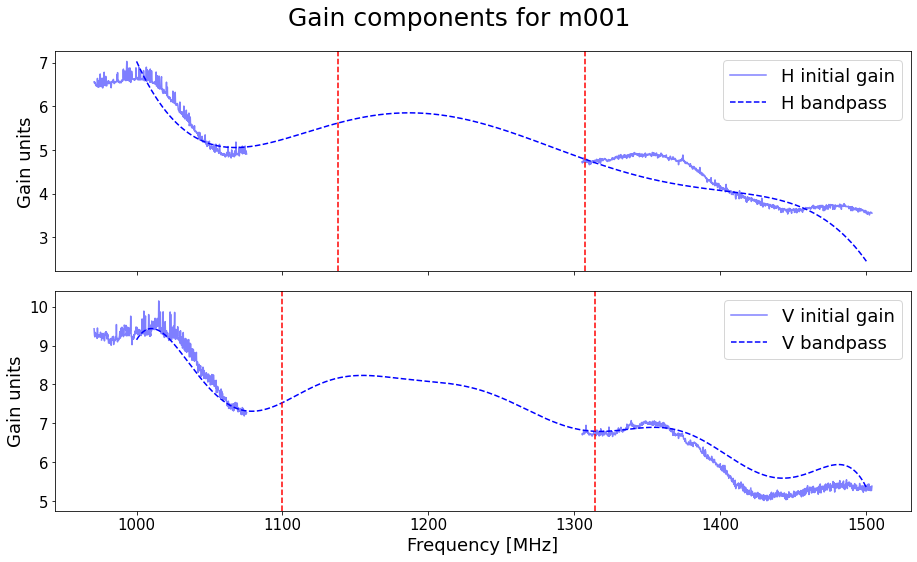

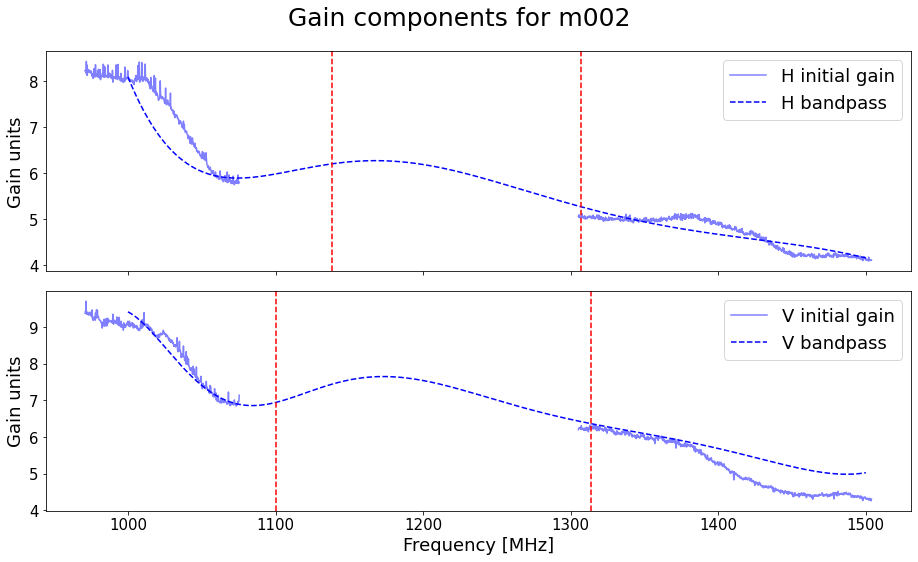

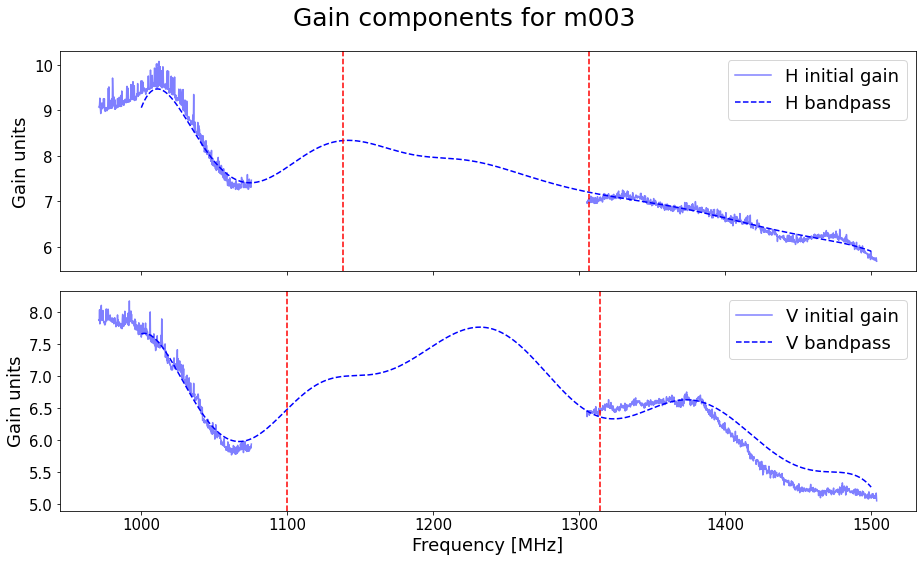

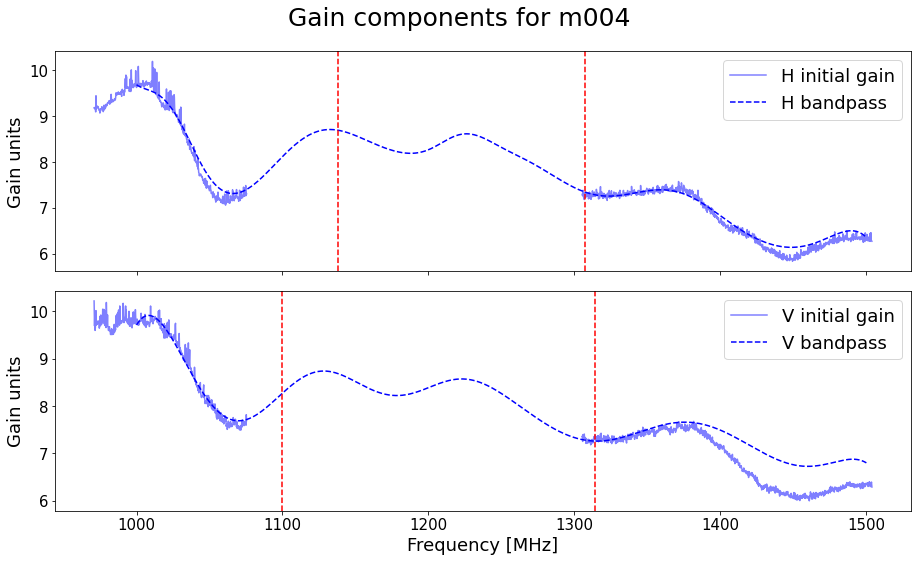

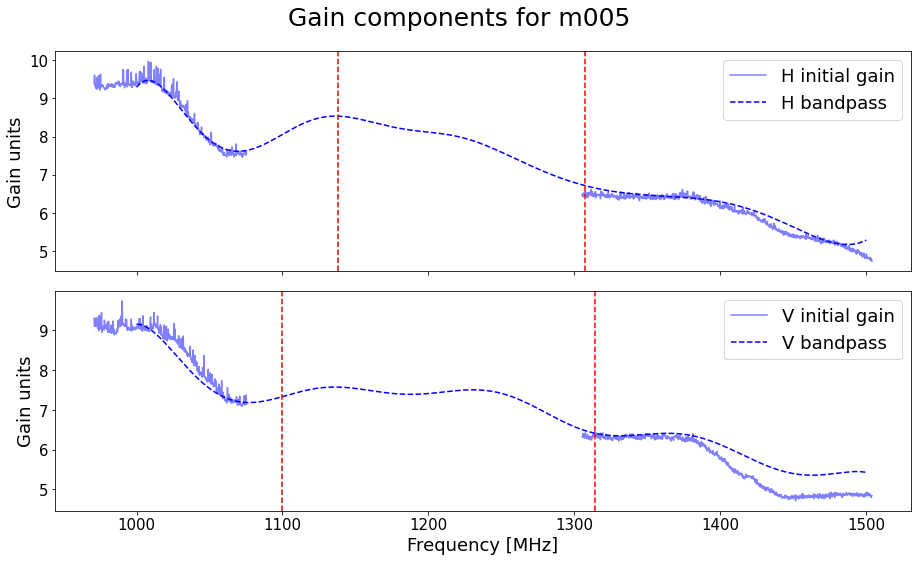

In [97]:
# plotting the two functions we are going to join
for ant in DR.good_antennas:

    # initial quantities
    gains = [gainH[ant], gainV[ant]]
    bps = [bpH[ant], bpV[ant]]

    # plotting
    fig, axs = plt.subplots(figsize=(13,8), nrows=2, ncols=1, sharex=True)
    for j in range(2):
        gain = np.ma.mean(gains[j], axis=0)
        bp = bps[j] / np.ma.max(bps[j]) * norms[ant][j] * np.ma.max(np.ma.mean(gains[j], axis=0))
        axs[j].plot(DR.frequency, gain, 'b', alpha=0.5, label='{} initial gain'.format(labels[j]))
        axs[j].plot(DR.frequency_cut, bp, 'b--', label='{} bandpass'.format(labels[j]))
        axs[j].axvline(freq_slices[j][0], color="r", linestyle="--")
        axs[j].axvline(freq_slices[j][1], color="r", linestyle="--")
        axs[j].set_ylabel("Gain units")
        axs[j].legend()
    axs[1].set_xlabel('Frequency [MHz]')
    fig.suptitle('Gain components for {}'.format(ant))
    fig.tight_layout()
    plt.show()


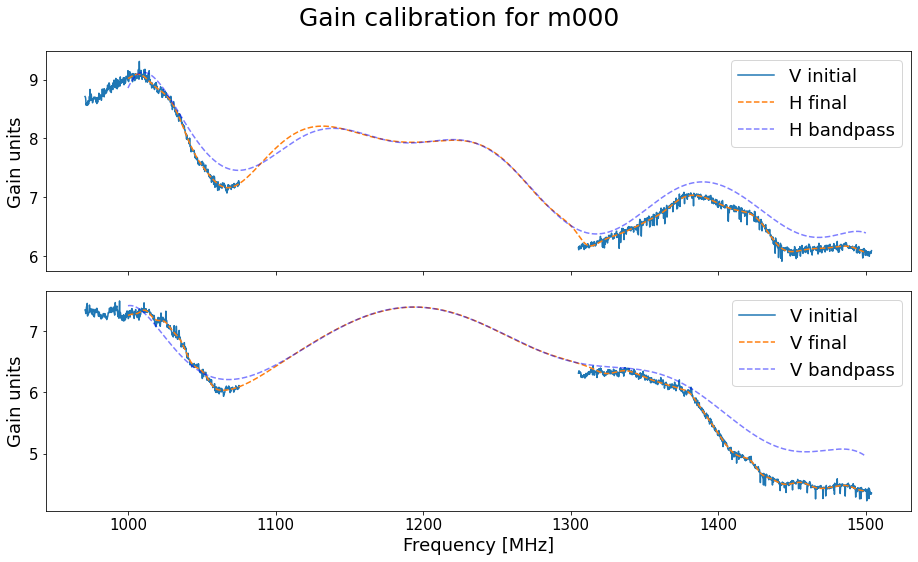

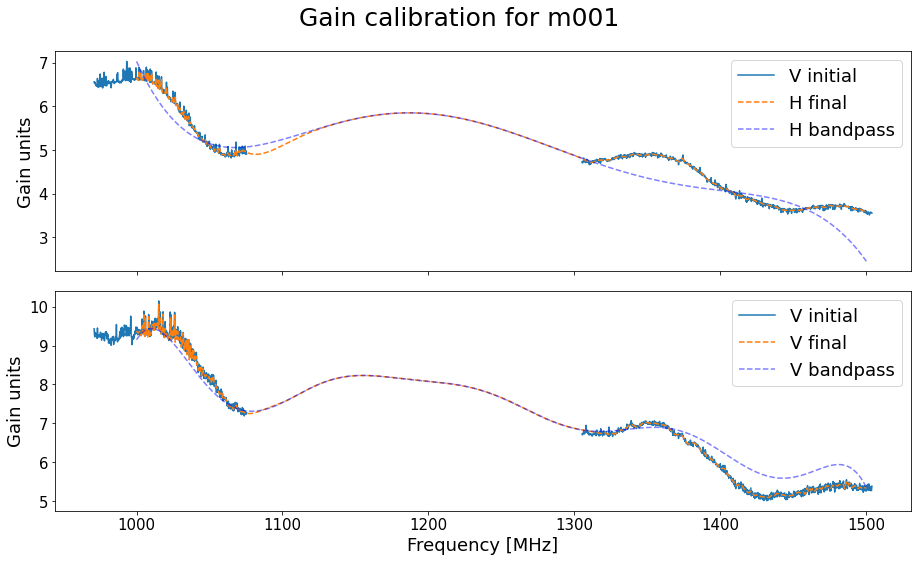

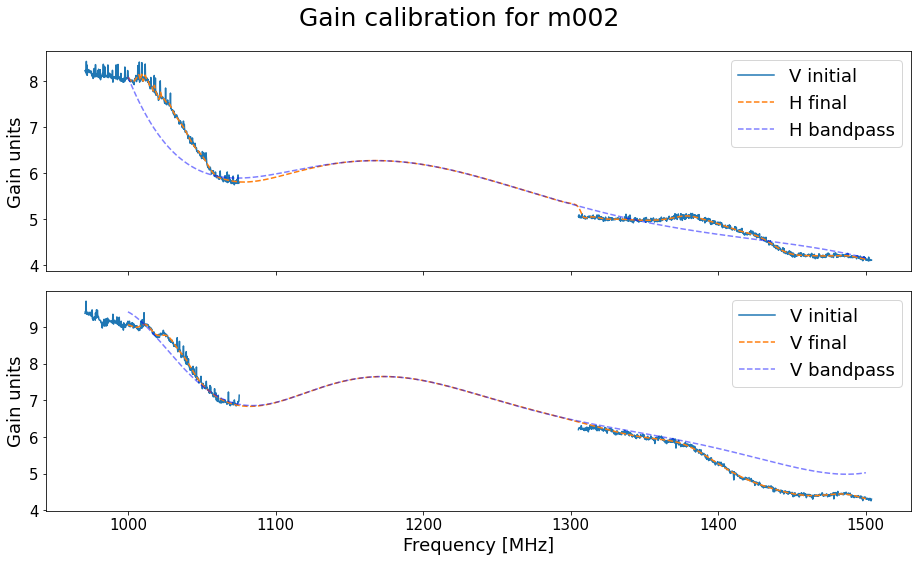

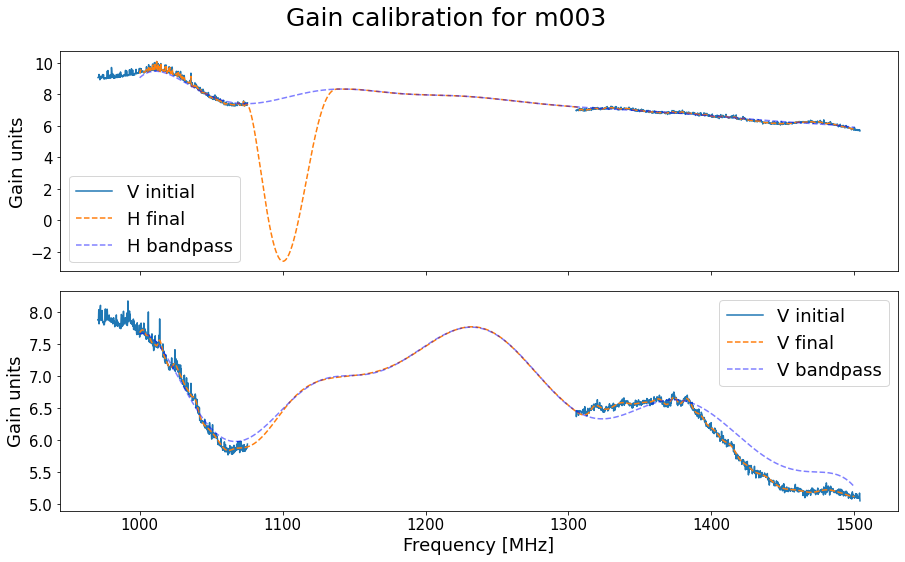

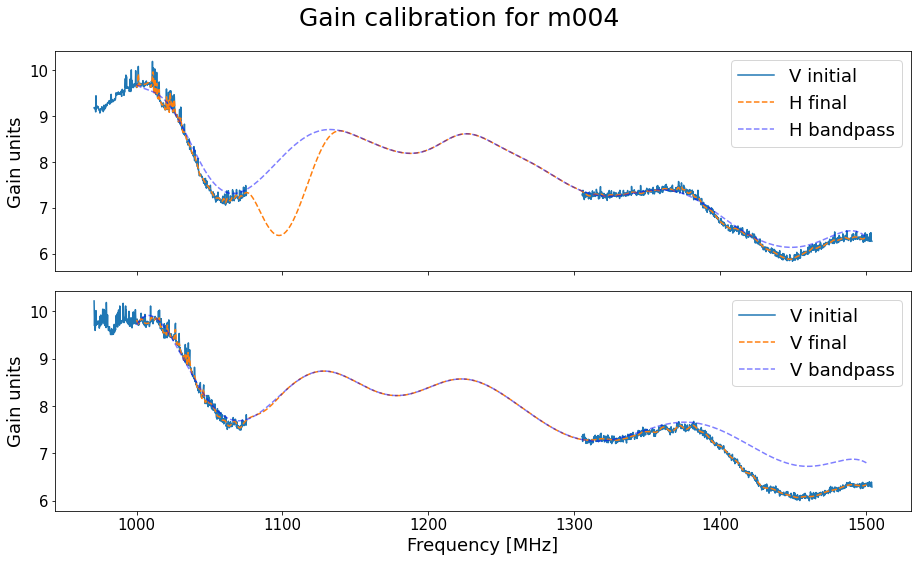

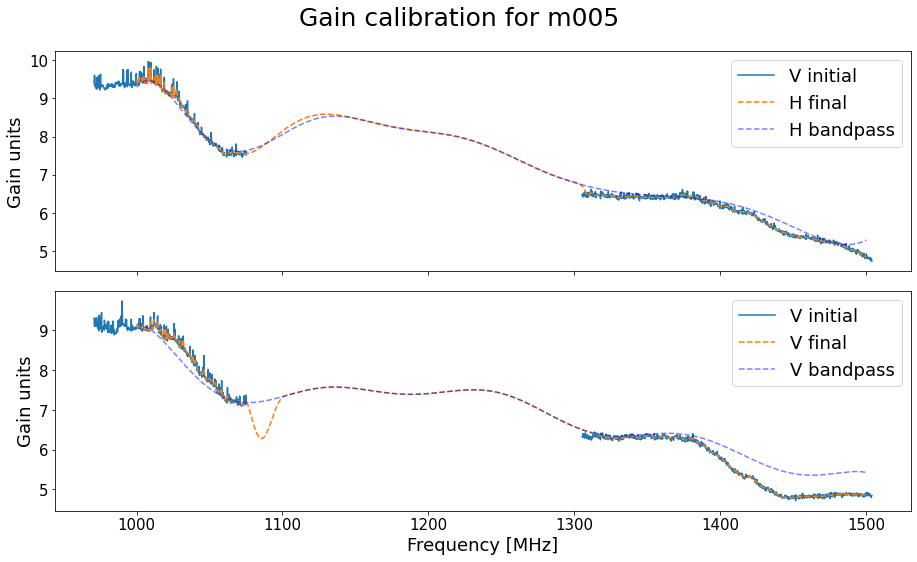

In [99]:
# computing final conjunction
data = {}
for ant in DR.good_antennas:

    # initial quantities
    gains = [gainH[ant], gainV[ant]]
    bps = [bpH[ant], bpV[ant]]
    fig, axs = plt.subplots(figsize=(13,8), nrows=2, ncols=1, sharex=True)
    
    for j in range(2):
        # calculating final gain curve
        gain_combined, gain_interp = DR.combine_gain_curves(
            gains[j], bps[j], norms[ant][j], freq_slices[j])
        data[labels[j]] = gain_interp(DR.frequency_cut)

        # plotting
        gain = np.ma.mean(gains[j], axis=0)
        bp = norms[ant][j] * bps[j] / np.ma.max(bps[j]) * np.ma.max(gain)
        axs[j].plot(DR.frequency, gain, label="{} initial".format(labels[i]))
        axs[j].plot(DR.frequency_cut, data[labels[j]] * np.ma.max(gain), "--", label="{} final".format(labels[j]))
        axs[j].plot(DR.frequency_cut, bp, 'b--', alpha=0.5, label='{} bandpass'.format(labels[j]))
        axs[j].set_ylabel("Gain units")
        axs[j].legend()
    axs[1].set_xlabel('Frequency [MHz]')
    fig.suptitle('Gain calibration for {}'.format(ant))
    fig.tight_layout()
    plt.show()

    # saving results
    data["frequency"] = DR.frequency_cut
    pickle.dump(data, open(pm.path_cali + "{}_fbandpass.p".format(ant), "wb"))


## 5. Creating final obs and obs_BG

Now we perform the last calculations, to obtain the quantities that are saved in the only file that we use in the simulation. The final file that has the quantities we need is called `_average_TOD_BG_model.p` and essentially just joins in a dictionary two quantities that are originally stored in the files `_gain_tod.p` and `_bg_model_no_con.p`. These will be the parts of the code that we rewrite, and the rest we'll leave untouched as it is not necessary.

### A. Building the final observations (`_gain_tod.p`)

We start by building the final gain files (which are the observations), and for this we use the previously calculated frequency bandpass. The other quantities are not used because they were initially uploaded with slightly different masks --- check if these are relevant or if I can use the same gain and visibility that I had already uploaded before.

In [ ]:
for i,ant in enumerate(DR.good_antennas):

    # getting values and saving
    obs = DR.final_observations(ant, path_results)
    pickle.dump(obs, open(f"{path_results}{ant}_observations.p", "wb"))
    

### B. Building the final background (`_bg_model_no_con.p`)

Now we do the background, which is simply the sum of each different component.

In [ ]:
for i,ant in enumerate(DR.good_antennas):

    # getting values and saving
    BG = DR.final_background(ant, path_results)
    pickle.dump(BG, open(f"{path_results}{ant}_background.p", "wb"))
    

### C. Building the constant factor for each antenna (`temp_residual`)

There is one more thing that needs to be added, which is the constant factor in each background temperature; it will differ by antenna. Up to this moment we have not considered this aspect (it was originally calculated at the same time as the functions .TOD() and .conversion(), but for celerity we'd excluded a lot of computations. As such, now we either change that function or, if it is a lot of independent computations, we write a new function for this constant value.

**NOTE: This is mostly done in A's function but needs objects from B, so the best thing is to put all A,B,C together in a single function and call it a day.**